# COGS 109 Final Project: Predicting Sleep Quality from Wearable Multisensor Data

**Team Members:** Anthony Mitine, Harshatha Prasanna, Yuxing Liu

## Introduction
Wearable devices provide a non-invasive way to monitor sleep and daily activity, but transforming raw physiological and movement data into meaningful sleep quality measures remains a challenge. In this project, we use the MMASH dataset, which includes participant sleep records, actigraphy data, heart rate, beat-to-beat interval data, activity logs, questionnaire scores, and demographic information. 

Our goal is to use multiple linear regression to predict a continuous sleep quality score from wearable and behavioral features such as heart rate, accelerometry, steps, body position, sleep duration, awakenings, and activity level. Since this dataset does not include REM sleep duration or skin temperature, our sleep quality score will instead be derived from available sleep-related variables such as total sleep time, latency efficiency, wake after sleep onset, number of awakenings, and sleep fragmentation index. Additionally, we will examine whether exercise level, measured through activity categories and wearable movement data, is correlated with sleep quality. By evaluating these relationships, we aim to better understand which physiological and behavioral factors are most associated with better or worse sleep outcomes.

## Methods
**Data Processing and Target Variable Construction**
The MMASH dataset is structured across 22 distinct participant folders, each containing individual CSV files (e.g., Actigraph.csv, RR.csv, Activity.csv, sleep.csv). Since the data collection spans a continuous 24-hour window split across two calendar days, Day 1 (approximately 09:30 to 23:59) and Day 2 (00:00 to approximately 09:30), our preprocessing script will iteratively access each user’s folder and chronologically merge the Day 1 and Day 2 continuous biosignals. This merging ensures we accurately capture a single, consolidated wake-sleep cycle per participant.

We will aggregate the second-by-second wearable data (such as heart rate and actigraphy) and categorical activity logs into daytime summary statistics (e.g., average daytime heart rate, total steps, and total minutes spent in "heavy" activity). Since the dataset does not provide a singular ground-truth sleep score, we will calculate a composite Sleep Quality Score (scaled from 0 to 100) based on the recorded metrics in sleep.csv. This score will be calculated as a weighted linear combination of positive restorative factors (Total Sleep Time, Latency Efficiency) penalized by sleep disruptions (Wake After Sleep Onset, Sleep Fragmentation Index, and Number of Awakenings).

**Data Analysis Approach & Rationale**
Our primary analytical approach will be Multiple Linear Regression. We are framing this problem with a focus on prediction, aiming to predict a continuous sleep quality score based on preceding daytime physiological and behavioral metrics. However, this approach also provides inference; by examining the resulting beta coefficients, we can infer which specific daytime variables (such as exercise intensity or step count) have the strongest statistical association with sleep quality.

This model class is appropriate because both our engineered target variable and our primary predictive features are continuous numerical data. Linear regression assumes an additive relationship between the independent variables and the outcome, which logically aligns with the hypothesis that cumulative daily behaviors aggregate to impact overall sleep restfulness.

**Model Estimation and Validation Strategy**
To ensure our model generalizes well to unseen data and avoids overfitting, we will utilize k-fold cross-validation (specifically, 5-fold cross-validation). First, we will randomly shuffle the order of our aggregated observations across the 22 users to remove any subject-ordering bias. The dataset is then split into 5 equal-sized subsets (folds). The model estimation process will iterate 5 times. During each iteration, the algorithm trains the regression model on 4 of the folds (80% of the data) and tests its predictive accuracy on the 1 remaining holdout fold (20% of the data). We will calculate the Mean Squared Error (MSE) for each fold, and the final reported cross-validation error will be the average of these 5 individual test errors.

**Model Selection**
To objectively evaluate our methodology, we will compare two variations of linear regression:
* **Baseline Multiple Linear Regression (Full Model):** We will estimate an Ordinary Least Squares (OLS) regression utilizing all available aggregated daytime predictors.
* **Lasso Regression (L1 Regularization):** Since many of our physiological predictors may be highly correlated (e.g., total steps and vector magnitude both measure movement), a standard linear model may suffer from multicollinearity. We will apply Lasso Regularization to penalize the absolute size of the regression coefficients. This technique acts as automatic feature selection by shrinking the coefficients of less important, noisy variables exactly to zero.

We will compare the 5-fold cross-validation MSE of both models to select the approach that maximizes predictive accuracy while minimizing unnecessary complexity.

In [1]:
# Import libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style="whitegrid")

### Data Wrangling & Aggregation
Iterating through the `data/user_*` directories to extract and aggregate daytime features and sleep target variables for each of the 22 users.

In [2]:
base_path = 'data'
compiled_data = []

# Loop through all 22 user folders
for i in range(1, 23):
    user_folder = f"user_{i}"
    user_path = os.path.join(base_path, user_folder)
    
    if not os.path.exists(user_path):
        continue
        
    user_dict = {'user_id': i}
    
    # Load User Info
    try:
        user_info = pd.read_csv(os.path.join(user_path, 'user_info.csv'))
        user_dict['age'] = user_info['Age'].values[0]
        user_dict['gender'] = user_info['Gender'].values[0]
        user_dict['bmi'] = user_info['Weight'].values[0] / ((user_info['Height'].values[0]/100)**2)
    except:
        pass

    # Load Sleep Data 
    try:
        sleep_df = pd.read_csv(os.path.join(user_path, 'sleep.csv'))
        user_dict['total_sleep_time'] = sleep_df['Total Sleep Time (TST)'].values[0]
        user_dict['latency_efficiency'] = sleep_df['Efficiency'].values[0]
        user_dict['waso'] = sleep_df['Wake After Sleep Onset (WASO)'].values[0]
        user_dict['awakenings'] = sleep_df['Number of Awakenings'].values[0]
        user_dict['sleep_frag_index'] = sleep_df['Sleep Fragmentation Index'].values[0]
    except:
        pass

    # Aggregate Actigraph Data 
    try:
        act_df = pd.read_csv(os.path.join(user_path, 'Actigraph.csv'))
        # Average daytime HR and total steps
        user_dict['avg_hr'] = act_df['HR'].mean()
        user_dict['total_steps'] = act_df['Steps'].sum()
        user_dict['mean_vector_mag'] = act_df['Vector Magnitude'].mean()
    except:
        pass
    
    # Aggregate Activity Log 
    try:
        activity_df = pd.read_csv(os.path.join(user_path, 'Activity.csv'))
        heavy_acts = activity_df[activity_df['Activity'] == 6]
        user_dict['heavy_activity_events'] = len(heavy_acts)
    except:
        pass
        
    compiled_data.append(user_dict)

# Create dataframe
df = pd.DataFrame(compiled_data)
df.head()

,user_id,age,gender,bmi,total_sleep_time,latency_efficiency,waso,awakenings,sleep_frag_index,avg_hr,total_steps,mean_vector_mag,heavy_activity_events
0,1,29,M,22.758307,144.0,87.27,21.0,9.0,19.091,84.719383,13625,42.201145,4
1,2,27,M,28.367524,244.0,73.49,84.0,18.0,20.616,74.532023,12415,37.210992,3
2,3,34,M,23.120624,351.0,79.23,89.0,16.0,18.962,77.538084,17822,40.162562,3
3,4,27,M,23.456790,319.0,85.52,50.0,28.0,23.133,71.918081,11958,37.652392,4
4,5,25,M,20.824656,348.0,85.71,58.0,21.0,21.100,74.884696,8129,26.695282,5


### Data Cleaning
Creating the continuous target variable: **Sleep Quality Score (0 - 100)**.
We will normalize positive factors (TST, Efficiency) and penalize them using normalized disruption factors (WASO, Awakenings, Fragmentation).

In [3]:
# Drop any users with missing vital data to ensure clean modeling
df = df.dropna().copy()

# Min-Max scale components between 0 and 1 for equal weighting
def min_max_scale(series):
    return (series - series.min()) / (series.max() - series.min())

# Positive factors 
scaled_tst = min_max_scale(df['total_sleep_time'])
scaled_eff = min_max_scale(df['latency_efficiency'])

# Negative factors (
inv_waso = 1 - min_max_scale(df['waso'])
inv_awake = 1 - min_max_scale(df['awakenings'])
inv_frag = 1 - min_max_scale(df['sleep_frag_index'])

# Composite Score Equation
# Weighting: 40% TST, 20% Efficiency, 15% WASO, 15% Awakenings, 10% Fragmentation
df['sleep_quality_score'] = ((scaled_tst * 40) + (scaled_eff * 20) + (inv_waso * 15) + (inv_awake * 15) + (inv_frag * 10))

# Display the distribution of our new target variable
df[['user_id', 'sleep_quality_score']].head()

,user_id,sleep_quality_score
0,1,48.227881
1,2,30.645749
2,3,46.445878
3,4,50.017850
4,5,54.785845


### Exploratory Data Analysis (EDA)

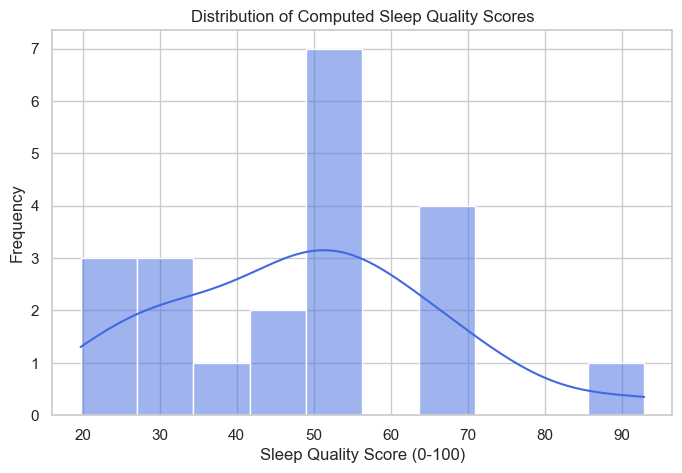

In [4]:
# Distribution of the Engineered Target Variable
plt.figure(figsize=(8, 5))
sns.histplot(df['sleep_quality_score'], bins=10, kde=True, color='royalblue')
plt.title('Distribution of Computed Sleep Quality Scores')
plt.xlabel('Sleep Quality Score (0-100)')
plt.ylabel('Frequency')
plt.show()

The computed Sleep Quality Scores form a roughly normal distribution centered around 50, with a wide spread of values ranging from the low 20s up to the 90s. This variance is ideal for our regression task; if the scores were highly clustered, our model would struggle to identify meaningful patterns.

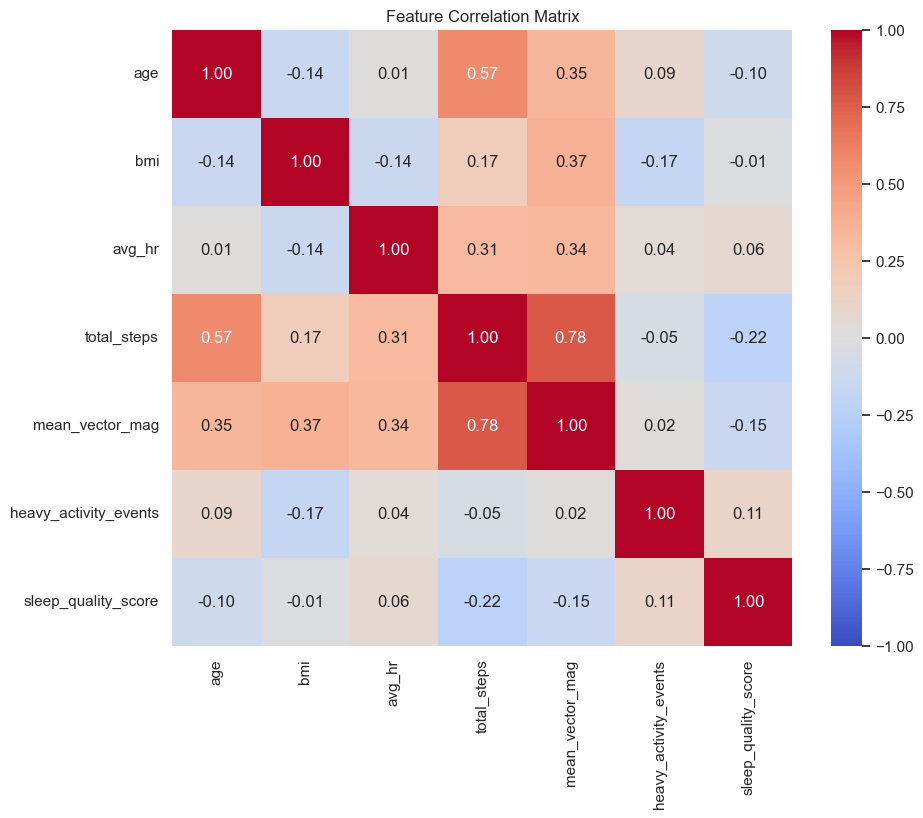

In [5]:
# Correlation Heatmap of Predictive Features vs Target
features = ['age', 'bmi', 'avg_hr', 'total_steps', 'mean_vector_mag', 'heavy_activity_events', 'sleep_quality_score']
corr_matrix = df[features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix')
plt.show()

The heatmap reveals a strong correlation (0.78) between `total_steps` and `mean_vector_mag`. This indicates high multicollinearity, meaning these two features provide redundant information about a user's daytime movement. This perfectly justifies our methodological choice to implement Lasso Regression, which will automatically penalize and shrink redundant coefficients. Additionally, we see that individual daytime features generally have weak linear correlations with the target variable (e.g., `total_steps` has a -0.22 correlation), suggesting that a multiple regression model combining several features will be necessary to achieve predictive accuracy.

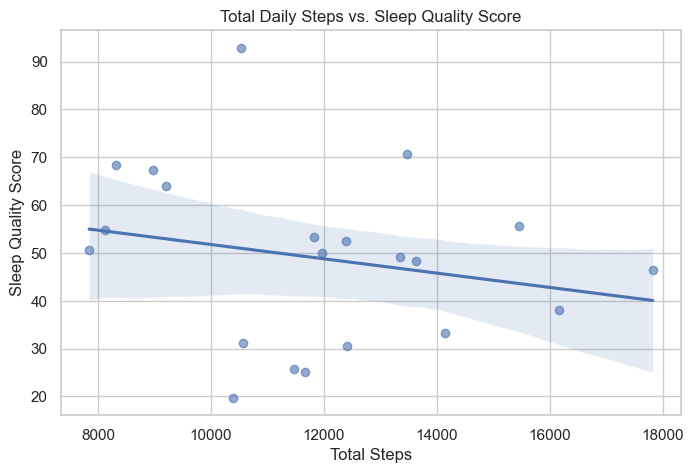

In [6]:
# Visualizing a potential relationship: Total Steps vs Sleep Quality
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='total_steps', y='sleep_quality_score', scatter_kws={'alpha':0.6})
plt.title('Total Daily Steps vs. Sleep Quality Score')
plt.xlabel('Total Steps')
plt.ylabel('Sleep Quality Score')
plt.show()

The scatter plot visualizes the slightly negative trend between daytime step count and our engineered sleep score. While counterintuitive, this highlights the complexity of physiological data, simply walking more does not automatically guarantee better sleep in this specific sample, further emphasizing the need for a multivariate approach.

### Data Preprocessing
Before model estimation, we must separate our predictors ($X$) from our target ($y$) and standardize the features. Standardization ensures that variables with vastly different scales (e.g., `total_steps` vs `heavy_activity_events`) are treated equally by the Lasso regularization penalty.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define features (X) and target (y)
feature_cols = ['age', 'bmi', 'avg_hr', 'total_steps', 'mean_vector_mag', 'heavy_activity_events']
X = df[feature_cols]
y = df['sleep_quality_score']

# Perform the Train/Test Split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the scaler
scaler = StandardScaler()

# Fit on training data 
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame 
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_cols)
X_train_scaled_df.head()

,age,bmi,avg_hr,total_steps,mean_vector_mag,heavy_activity_events
0,0.063436,-1.719854,1.872866,-0.022396,0.294663,-0.718902
1,-0.190308,0.159113,0.094646,-0.455605,-0.538131,-1.603704
2,0.063436,0.513671,-0.470969,0.021028,0.685054,0.165900
3,0.317181,0.169243,-0.780953,-0.999937,-1.093444,0.165900
4,-3.362116,1.222788,-0.696597,-1.386645,-1.363104,-0.718902
